# P2.8 · Nonlinearity and GELU

**Maths fundamentals for transformers · Tiny Transformer**

Two affine layers without an intervening nonlinearity can be combined into one affine layer.

**You will be able to:** GELU bends each hidden value smoothly, allowing two learned linear layers to express more than one affine transformation.

This notebook runs independently in Jupyter or Google Colab on a CPU. Download it from the course, then use **Colab → File → Upload notebook**. Public publication target: https://github.com/gkiri/tiny_repo. All required numerical examples are included.

The model connection uses the same **9,417-parameter transformer** as Unit 1: 65 characters, 32 positions, 28 features, two heads, learned position embeddings, LayerNorm and GELU.

In [1]:
#@title Setup: CPU, local Jupyter or Google Colab { display-mode: "form" }
# This notebook is self-contained. No account, secret, repository clone or GPU is required.
import sys, math, json, base64, zlib, hashlib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(7)
torch.set_num_threads(1)
plt.rcParams.update({"figure.figsize": (7, 3), "figure.dpi": 100, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .18})
print("Ready on CPU · PyTorch", torch.__version__)
print("All example data is included in this notebook.")

Ready on CPU · PyTorch 2.10.0+cpu
All example data is included in this notebook.


## Predict first

Why does a feed-forward network need a bend?

Write down your prediction before running the calculation.

Is GELU(−1) exactly zero? Set answer to True or False.

## Work the numbers

1. Two affine layers collapse into one

2. Φ(x): shaded standard-normal area to the left of x

3. Multiply: x × Φ(x)

4. GELU(−1) ≈ −0.159; GELU(1) ≈ 0.841

$$\operatorname{GELU}(x)=x\Phi(x)=\frac{x}{2}\left(1+\operatorname{erf}\left(\frac{x}{\sqrt2}\right)\right)$$

These small numbers are **Illustrative**. Each symbol names a quantity already shown above.

In [2]:
#@title Explicit teaching functions (expand to inspect) { display-mode: "form" }
"""P2's explicit calculations. Each function is checked against an independent PyTorch operation.

Rows use the final axis for features. Linear weights use PyTorch's [out, in] convention.
These readable implementations teach the operations; the reference model remains unchanged.
"""
import math
import torch


def dot(x, y):
    if x.shape != y.shape or x.ndim != 1:
        raise ValueError("dot needs two vectors of the same length")
    return (x * y).sum()


def linear(x, weight, bias):
    return x @ weight.transpose(-2, -1) + bias


def embeddings(ids, token_table, position_table):
    positions = torch.arange(ids.shape[-1], device=ids.device)
    if ids.shape[-1] > position_table.shape[0]:
        raise ValueError("the position table is shorter than the input")
    return token_table[ids] + position_table[positions]


def layernorm(x, gamma, beta, eps=1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    variance = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
    return (x - mean) / torch.sqrt(variance + eps) * gamma + beta


def softmax(scores, temperature=1.0):
    if temperature <= 0 or not math.isfinite(temperature):
        raise ValueError("temperature must be finite and positive")
    if torch.isnan(scores).any() or torch.isposinf(scores).any() or torch.isneginf(scores).all(dim=-1).any():
        raise ValueError("each score row needs a finite entry, with no NaN or positive infinity")
    scaled = scores / temperature
    shifted = scaled - scaled.max(dim=-1, keepdim=True).values
    positive = torch.exp(shifted)
    return positive / positive.sum(dim=-1, keepdim=True)


def attention(q, k, v):
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    allowed = torch.ones(scores.shape[-2:], dtype=torch.bool, device=q.device).tril()
    masked = scores.masked_fill(~allowed, float("-inf"))
    shares = softmax(masked)
    return shares @ v, shares, masked


def gelu(x):
    cdf = 0.5 * (1 + torch.erf(x / math.sqrt(2)))
    return x * cdf


def residual(x, update):
    if x.shape != update.shape:
        raise ValueError("a residual update must have the same shape as its input")
    return x + update


def cross_entropy(logits, targets):
    log_prob = logits - torch.logsumexp(logits, dim=-1, keepdim=True)
    correct = log_prob.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    return -correct.mean()


def tiny_loss(w):
    """One adjustable logit: target 0, logits [2*w, 1, 0]."""
    z = torch.stack((2 * w, torch.ones_like(w), torch.zeros_like(w)))
    return cross_entropy(z.unsqueeze(0), torch.tensor([0], device=w.device))


def finite_difference(f, x, step=1e-5):
    return (f(x + step) - f(x - step)) / (2 * step)


def adamw_step(parameter, gradient, first, second, step, lr=0.003,
               betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01):
    """One AdamW update, including moment bias correction and decoupled weight decay."""
    beta1, beta2 = betas
    first = beta1 * first + (1 - beta1) * gradient
    second = beta2 * second + (1 - beta2) * gradient.square()
    first_hat = first / (1 - beta1 ** step)
    second_hat = second / (1 - beta2 ** step)
    parameter = parameter * (1 - lr * weight_decay) - lr * first_hat / (second_hat.sqrt() + eps)
    return parameter, first, second

print("Explicit functions loaded; each is independently tested against PyTorch.")

Explicit functions loaded; each is independently tested against PyTorch.


## Implement and verify

Read each line, predict its output, then run it. The explicit calculation and the PyTorch operation should agree.

In [3]:
x = torch.tensor([-2., -1., 0., 1., 2.])
cdf = .5 * (1 + torch.erf(x / math.sqrt(2)))
y = x * cdf
print("input", x.tolist())
print("GELU", [round(v, 4) for v in y.tolist()])
torch.testing.assert_close(y, F.gelu(x, approximate='none'))
print("ReLU for comparison", torch.relu(x).tolist())

input [-2.0, -1.0, 0.0, 1.0, 2.0]
GELU [-0.0455, -0.1587, 0.0, 0.8413, 1.9545]
ReLU for comparison [0.0, 0.0, 0.0, 1.0, 2.0]


## See it and change one thing

The plot is generated by the code. Change one input and predict how the picture will change before running it again.

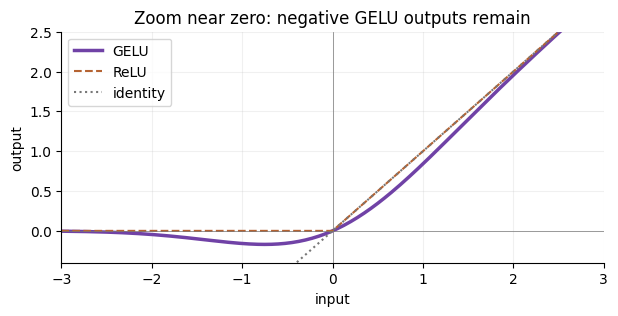

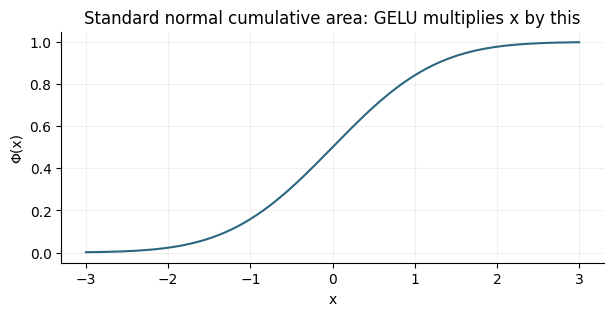

In [4]:
grid=torch.linspace(-3,3,241)
plt.plot(grid, F.gelu(grid), label="GELU",color="#7042a6",lw=2.5)
plt.plot(grid, F.relu(grid), "--", label="ReLU",color="#b56332")
plt.plot(grid, grid, ":", label="identity",color="#777")
plt.axhline(0,color="#777",lw=.5);plt.axvline(0,color="#777",lw=.5)
plt.xlim(-3,3);plt.ylim(-.4,2.5);plt.xlabel("input");plt.ylabel("output");plt.legend();plt.title("Zoom near zero: negative GELU outputs remain");plt.show()
phi=.5*(1+torch.erf(grid/math.sqrt(2)))
plt.plot(grid,phi,color="#2b6680");plt.xlabel("x");plt.ylabel("Φ(x)");plt.title("Standard normal cumulative area: GELU multiplies x by this");plt.show()

## Find it in the transformer

The following values were exported at full precision from the pinned Unit 1 checkpoint. Crops are for display; complete vectors are used in calculations.

Recorded input: `You taught me language; and my p`.

Reference lesson: **inside-feed-forward**.

In [5]:
#@title Recorded model fixture (included; no download) { display-mode: "form" }
recorded = json.loads('{"hidden":[0.9292588233947754,-0.3947002589702606,-3.848655939102173,2.641138792037964,0.8741299510002136,-3.5750393867492676,-1.1303330659866333,-2.172542095184326,-8.045830726623535,0.6792605519294739,-1.466484546661377,-0.5009048581123352,-0.9560755491256714,-1.5481536388397217,-5.905663967132568,-1.0169868469238281,-0.3269253373146057,-1.3338669538497925,-0.6842527389526367,-0.7365871667861938,-3.55570125579834,0.8250189423561096,-2.2109179496765137,-3.4815242290496826,-8.877511024475098,-3.1660468578338623,-5.294065475463867,-1.1988859176635742,-0.8689383268356323,1.3174529075622559,-1.1149818897247314,1.2416813373565674,-2.74664306640625,1.2854902744293213,3.1205339431762695,-4.363018035888672,0.7774530649185181,-0.625480592250824,0.3343905210494995,-9.225909233093262,-0.7417657971382141,-4.200112819671631,-3.268637180328369,-7.1553053855896,-2.1383752822875977,0.7220930457115173,-0.23199859261512756,1.3476197719573975,-1.0657854080200195,-6.1716814041137695,1.064978837966919,-0.7396056056022644,-7.399935245513916,-2.2145087718963623,-6.008998870849609,3.5760364532470703],"gelu":[0.7653584480285645,-0.13677628338336945,-0.00022836547577753663,2.6302273273468018,0.707150399684906,-0.000625629152636975,-0.14600279927253723,-0.032386865466833115,-0.0,0.5104735493659973,-0.10449894517660141,-0.1543883979320526,-0.162071093916893,-0.09411636739969254,-0.0,-0.15720564126968384,-0.12157116830348969,-0.12154693156480789,-0.16894733905792236,-0.1699208766222,-0.0006704605184495449,0.656153678894043,-0.029893329367041588,-0.0008676202851347625,-0.0,-0.0024462619330734015,-3.155508920826833e-07,-0.13821493089199066,-0.167218878865242,1.1938185691833496,-0.14765603840351105,1.1086015701293945,-0.008268882520496845,1.157827615737915,3.117717981338501,-2.7956035410170443e-05,0.6076217293739319,-0.1662701517343521,0.21098622679710388,-0.0,-0.16994939744472504,-5.5827211326686665e-05,-0.0017659025033935905,-0.0,-0.03473396971821785,0.5523155331611633,-0.09471796452999115,1.2278294563293457,-0.1526847630739212,-0.0,0.9122153520584106,-0.16993893682956696,-0.0,-0.029667461290955544,-0.0,3.5754125118255615]}')
print("Recorded: prompter-r1; input: You taught me language; and my p")

Recorded: prompter-r1; input: You taught me language; and my p


In [6]:
h=torch.tensor(recorded["hidden"]);g=torch.tensor(recorded["gelu"]);torch.testing.assert_close(F.gelu(h),g,atol=2e-6,rtol=2e-5);print("56 hidden inputs; maximum difference",(F.gelu(h)-g).abs().max().item())

56 hidden inputs; maximum difference 0.0


## A common trap

GELU does not set all negatives to zero or pass every positive unchanged. Φ is a deterministic multiplier here, not a random decision.

### ✋ Your turn

Is GELU(−1) exactly zero? Set answer to True or False.

In [7]:
answer = None  # TODO: make a prediction, then enter your answer

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer is False, 'Revisit the worked calculation above.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
answer = False

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer is False, 'Revisit the worked calculation above.'
    print("✓ right:", answer)

✓ right: False


## Connect the dots

GELU bends each hidden value smoothly, allowing two learned linear layers to express more than one affine transformation.

Next: residual additions.

To explain this operation to someone else, name its inputs, calculate one output, give its PyTorch equivalent, and point to its place in the transformer.